# Part I. Using PCA to project 2-D data onto its principal axes

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn import datasets
from sklearn.preprocessing import StandardScaler

## Create dataset

In [2]:
np.random.seed(42)
mean = [0, 0]
cov = [[3, 2], [2, 2]]
x = np.random.multivariate_normal(mean=mean, cov=cov, size=200)

## Visualize the relationship between the two features.

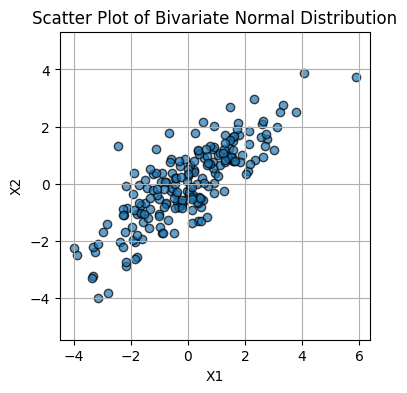

In [3]:
plt.figure(figsize=(4,4))
plt.scatter(x[:, 0], x[:, 1],  edgecolor='k', alpha=0.7)
plt.title("Scatter Plot of Bivariate Normal Distribution")
plt.xlabel("X1")
plt.ylabel("X2")
plt.axis('equal')
plt.grid(True)
plt.show()

## Perform PCA on the dataset

In [4]:
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x)

## Get the principal components from the model

In [5]:
components = pca.components_
components
pca.explained_variance_ratio_

array([0.9111946, 0.0888054])

## Project the data onto its principal component axes

In [6]:
projections_pc1 = np.dot(x, components[0])
projections_pc2 = np.dot(x, components[1])

x_pc1 = projections_pc1 * components[0, 0]
y_pc1 = projections_pc2 * components[0, 1]
x_pc2 = projections_pc1 * components[1, 0]
y_pc2 = projections_pc2 * components[1, 1]

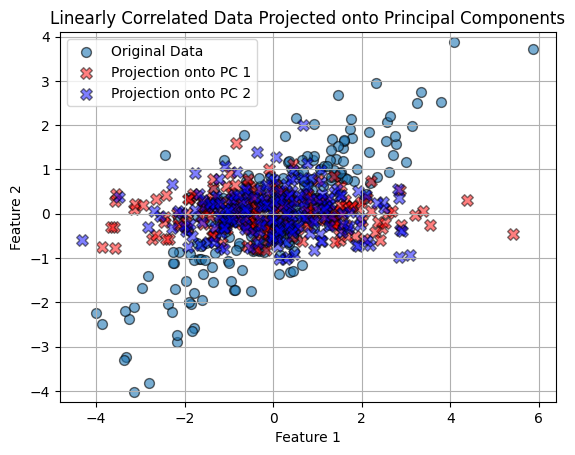

In [7]:
plt.figure()
plt.scatter(x[:, 0], x[:, 1], label='Original Data', ec='k', s=50, alpha=0.6)

# Plot the projections along PC1 and PC2
plt.scatter(x_pc1, y_pc1, c='r', ec='k', marker='X', s=70, alpha=0.5, label='Projection onto PC 1')
plt.scatter(x_pc2, y_pc2, c='b', ec='k', marker='X', s=70, alpha=0.5, label='Projection onto PC 2')
plt.title('Linearly Correlated Data Projected onto Principal Components', )
plt.xlabel('Feature 1',)
plt.ylabel('Feature 2',)
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

# Part II. PCA for feature space dimensionality reduction

In [8]:
iris = datasets.load_iris()
x = iris.data
y = iris.target
target_names = iris.target_names

scale = StandardScaler()
x_scale = scale.fit_transform(x)

In [9]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

## Initialize a PCA model and reduce the Iris data set dimensionality to two components


In [14]:
pca = PCA(n_components = 2)
x_pca = pca.fit_transform(x_scale)
explained_variance_ratio = pca.explained_variance_ratio_

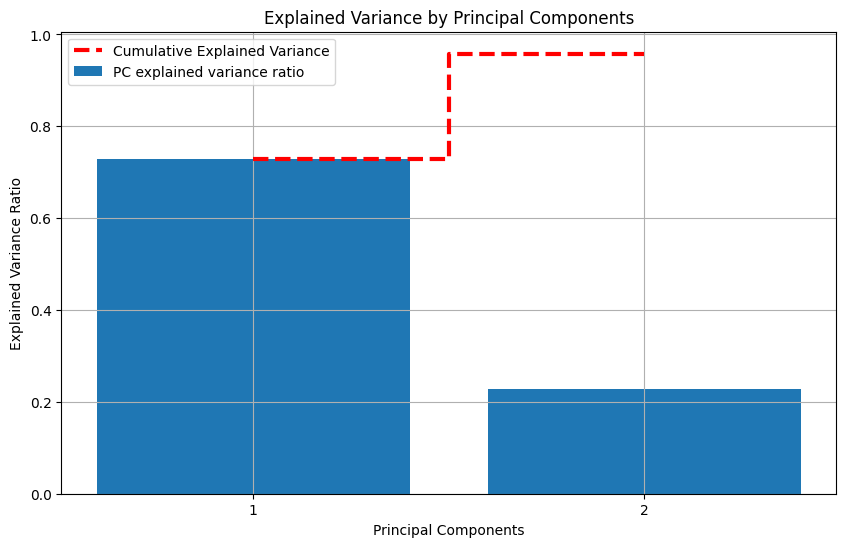

In [17]:
# Plot explained variance ratio for each component
plt.figure(figsize=(10,6))
plt.bar(x=range(1, len(explained_variance_ratio)+1), height=explained_variance_ratio, alpha=1, align='center', label='PC explained variance ratio' )
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Components')
plt.title('Explained Variance by Principal Components')

# Plot cumulative explained variance
cumulative_variance = np.cumsum(explained_variance_ratio)
plt.step(range(1, len(cumulative_variance) + 1), cumulative_variance, where='mid', linestyle='--', lw=3,color='red', label='Cumulative Explained Variance')
# Only display integer ticks on the x-axis
plt.xticks(range(1, len(cumulative_variance) + 1))
plt.legend()
plt.grid(True)
plt.show()